Cancelation and Delay analysis

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

In [3]:
import plotly.express as px
import nbformat
import plotly.graph_objects as go

In [4]:
cancellation = pd.read_csv("Airline_Delay_Cause.csv") 

In [5]:
cancellation.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2025,1,G4,Allegiant Air,ELM,"Elmira/Corning, NY: Elmira/Corning Regional",30.0,0.0,0.00,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2025,1,G4,Allegiant Air,ELP,"El Paso, TX: El Paso International",2.0,0.0,0.00,0.0,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2025,1,G4,Allegiant Air,EUG,"Eugene, OR: Mahlon Sweet Field",28.0,8.0,3.74,0.0,...,0.0,2.66,2.0,0.0,409.0,236.0,0.0,70.0,0.0,103.0
3,2025,1,G4,Allegiant Air,EVV,"Evansville, IN: Evansville Regional",18.0,1.0,0.00,1.0,...,0.0,0.00,0.0,0.0,1075.0,0.0,1075.0,0.0,0.0,0.0
4,2025,1,G4,Allegiant Air,EWR,"Newark, NJ: Newark Liberty International",31.0,5.0,2.17,0.0,...,0.0,0.00,1.0,0.0,446.0,336.0,0.0,110.0,0.0,0.0


In [6]:
cancellation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165600 entries, 0 to 165599
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 165600 non-null  int64  
 1   month                165600 non-null  int64  
 2   carrier              165600 non-null  object 
 3   carrier_name         165600 non-null  object 
 4   airport              165600 non-null  object 
 5   airport_name         165600 non-null  object 
 6   arr_flights          165284 non-null  float64
 7   arr_del15            165039 non-null  float64
 8   carrier_ct           165284 non-null  float64
 9   weather_ct           165284 non-null  float64
 10  nas_ct               165284 non-null  float64
 11  security_ct          165284 non-null  float64
 12  late_aircraft_ct     165284 non-null  float64
 13  arr_cancelled        165284 non-null  float64
 14  arr_diverted         165284 non-null  float64
 15  arr_delay        

In [7]:
cancellation.dropna(inplace=True)

In [8]:
cancellation['quarter'] = ((cancellation['month'] - 1) // 3) + 1

In [9]:
filtered = cancellation[cancellation['year'].isin([2019, 2020, 2021, 2022, 2023, 2024])]

Delays

<Axes: xlabel='year,quarter'>

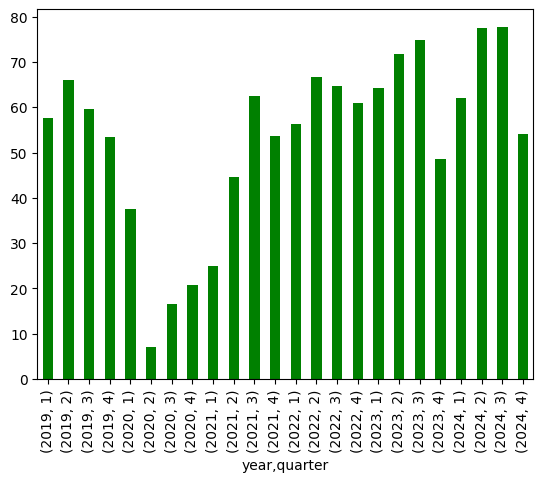

In [13]:
delay_by_month = filtered.groupby(['year','quarter'])['arr_del15'].mean()

delay_by_month.plot(kind = 'bar', color='green')

<Axes: xlabel='year,quarter'>

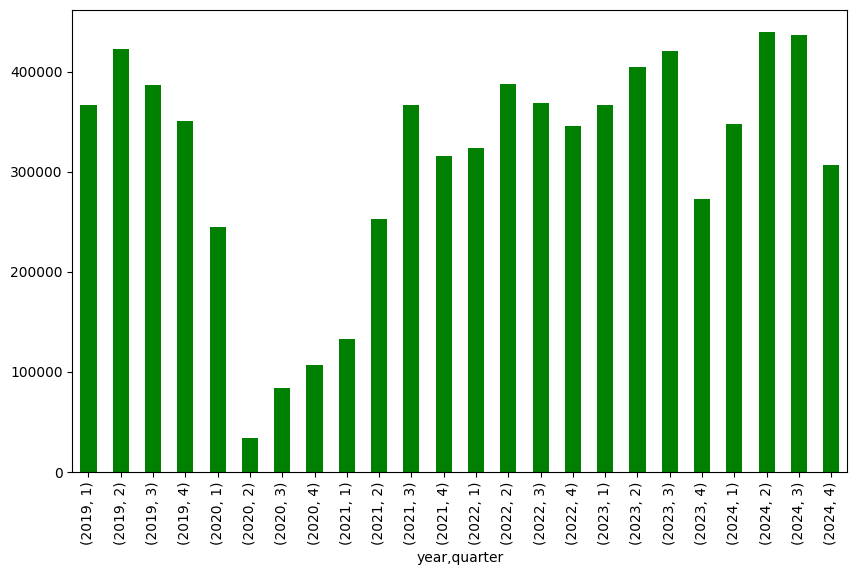

In [14]:
delay_by_month = filtered.groupby(['year','quarter'])['arr_del15'].sum()

delay_by_month.plot(kind = 'bar', color='green', figsize=(10, 6))

In [10]:
delay_by_month = cancellation.groupby(['year','quarter'])['arr_del15'].mean().reset_index()

Cancellations


<Axes: xlabel='year,quarter'>

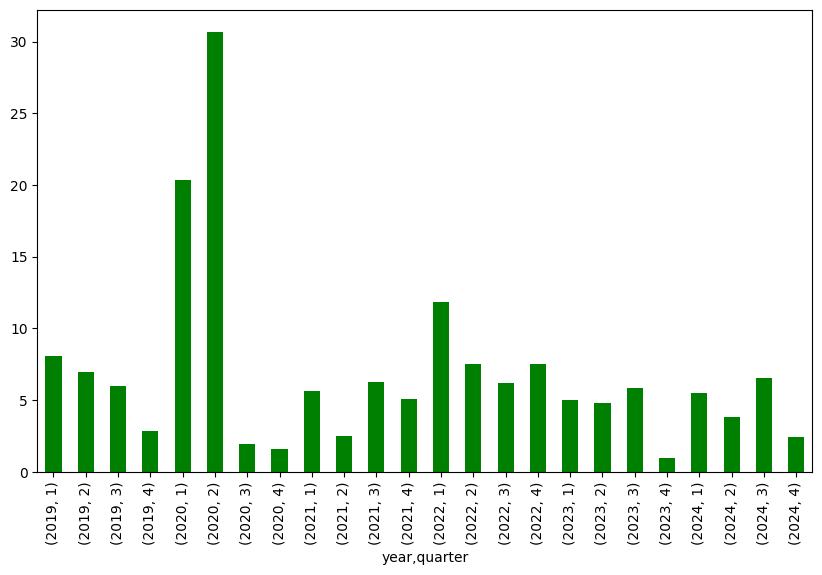

In [11]:
delay_by_month = filtered.groupby(['year','quarter'])['arr_cancelled'].mean()

delay_by_month.plot(kind = 'bar', color='green', figsize=(10, 6))

<Axes: xlabel='year,quarter'>

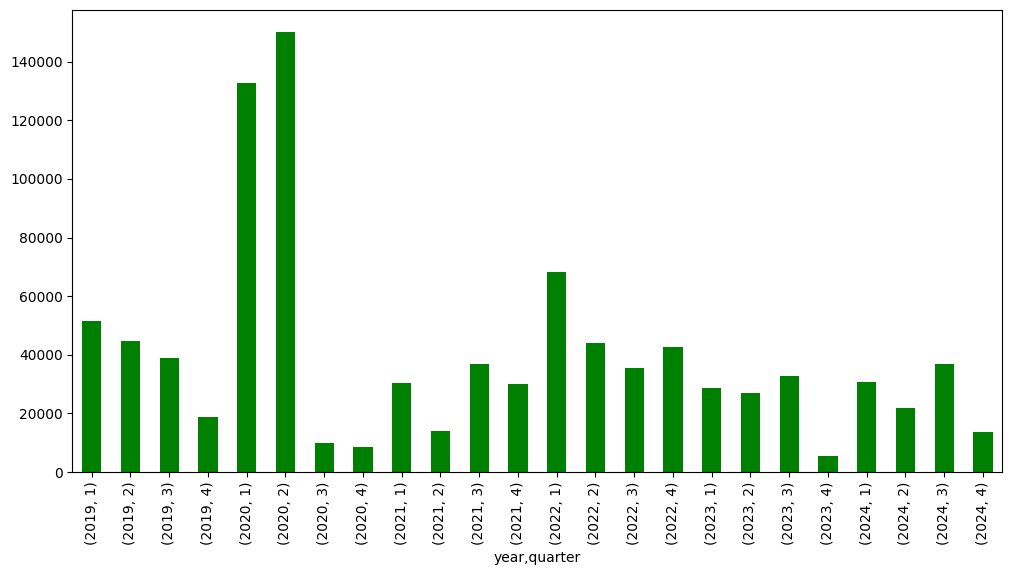

In [21]:
delay_by_month = filtered.groupby(['year','quarter'])['arr_cancelled'].sum()

delay_by_month.plot(kind = 'bar', color='green', figsize=(12, 6))

In [17]:
delay_by_month = cancellation.groupby(['year','quarter'])['arr_cancelled'].mean().reset_index()

In [18]:
delay_by_month = filtered.groupby(['year','quarter'])['arr_del15'].mean()
cancel_by_month = filtered.groupby(['year','quarter'])['arr_cancelled'].mean()

In [19]:
comparison = pd.concat([delay_by_month, cancel_by_month], axis=1)
comparison.columns = ['Delays', 'Cancellations']

In [20]:
comparison = comparison.dropna().sort_values(by='Delays', ascending=False)
comparison = comparison.reset_index()

In [21]:
fig = px.bar(
    comparison,
    x='year',
    y=['Delays', 'Cancellations'],
    barmode='group',
    title='Cancellations & Delays',
    labels={'value': 'Count'}
)
fig.update_layout(
    legend_title_text='Metric' ,
    xaxis=dict(title='Year'),
)

fig.show()